# detecting pulmonary embolism in ct scans

## the problem
a **pulmonary embolism (pe)** is a blood clot blocking an artery in the lungs. it's common, dangerous, and easy to miss: radiologists have to scroll through hundreds of ct slices per patient looking for small dark spots inside the arteries.

**goal:** a model that looks at a patient's ct scan and decides **"pe or no pe"**, with **high recall** as the priority. in this setting, missing a sick patient is far worse than a false alarm, which a doctor can rule out.

## the data
the **rsna str pulmonary embolism detection** dataset (rsna, 2020): ct pulmonary angiography scans from five international centers, labeled by expert thoracic radiologists.
- labels exist **per slice** (`pe_present_on_image`) and **per patient** (exam-level)
- we use a subset of **3000 patients**, split **by patient** into train / validation / test (70 / 15 / 15) so no patient appears in two sets
- exams marked **indeterminate** (image quality too poor to decide) are excluded
- about **31%** of patients have pe, but only **~5%** of slices contain a clot, so the data is heavily imbalanced

## the approach
1. **preprocessing:** each scan is windowed to highlight blood and clots, resized to 256×256, and reduced to 64 evenly spaced slices
2. **stage 1 (slice level):** a cnn scores each slice for "clot or not", using 3 neighboring slices as input channels ("2.5d") for some 3d context. we compare three models: a small cnn from scratch, resnet18 and efficientnet-b0
3. **stage 2 (patient level):** the best stage 1 model's slice scores are combined into one patient decision
4. **threshold tuning:** instead of the default 0.5, we choose the cutoff that reaches ~90% recall on validation, and report precision and specificity alongside it, since recall alone can be faked by flagging everyone
5. **final test:** the chosen model and cutoff are evaluated **once** on test patients never used during development

## notebook structure
| cells | what happens |
|---|---|
| 1–2 | locate the data, select patients, split by patient |
| 3–4 | preprocessing: squish each scan into 64 small slices |
| 5–6 | build the slice table, dataset, augmentation, class weighting |
| 6.5 | visual check of the augmentation |
| stage 1 | train and compare pe_ct_cnn, resnet18, efficientnet-b0 |
| stage 2 | patient-level model on top of the best slice model |
| final | test set evaluation |

deployment (a gradio app with image upload and camera input) lives in a separate inference notebook.

**data source:** Colak et al., *The RSNA Pulmonary Embolism CT Dataset*, Radiology: Artificial Intelligence, 2021.

### 1. locate the data
kaggle mounts the competition data as read-only files. this cell lists the input folders so we know the exact path, and installs the decoders needed for compressed (jpeg-lossless) dicom files, which some hospitals in the dataset use.

In [1]:
#1
!pip install -q pylibjpeg pylibjpeg-libjpeg python-gdcm
import os, glob

for root in glob.glob("/kaggle/input/*") + glob.glob("/kaggle/input/*/*"):
    print(root)

#were asking here where is the data exactly, 
    #folders are printed so we know where the data is exactly

/kaggle/input/competitions
/kaggle/input/competitions/rsna-str-pulmonary-embolism-detection


### 2. select patients and split them
- `train.csv` has one row per **slice**; we collapse it to one row per **patient** with a sick/healthy label
- **indeterminate** exams (image quality too poor to decide) are dropped, since they are neither confirmed pe nor confirmed healthy
- we use **3000 patients**, keeping the real sick/healthy ratio (~31% sick)
- the split is **by patient** (70% train, 15% validation, 15% test), so slices from one person never appear in two sets. splitting by slice would leak near-identical images between sets and inflate scores

In [2]:
#2
import pandas as pd
from sklearn.model_selection import train_test_split

data_home = "/kaggle/input/competitions/rsna-str-pulmonary-embolism-detection"
print(os.listdir(data_home))

df = pd.read_csv(f"{data_home}/train.csv")
print("slices:", len(df))

# one row per patient. drop "indeterminate" exams (scan too bad to decide)
pts = df.groupby("StudyInstanceUID")[["negative_exam_for_pe", "indeterminate"]].first().reset_index()
pts = pts[pts.indeterminate == 0]
pts["has_pe"] = 1 - pts["negative_exam_for_pe"]
print("patients:", len(pts))
print("sick ratio:", round(pts.has_pe.mean(), 3))

how_many = 3000

# reuse patients already squished, add new random ones on top
already = {os.path.basename(f)[:-4] for f in glob.glob("/kaggle/working/scans/*.npz")}
old_ones = pts[pts.StudyInstanceUID.isin(already)]
new_pool = pts[~pts.StudyInstanceUID.isin(already)]
need = how_many - len(old_ones)
if need > 0:                                   # not enough on disk -> add new ones
    extra, _ = train_test_split(new_pool, train_size=need,
                                stratify=new_pool.has_pe, random_state=42)
    picked = pd.concat([old_ones, extra]).reset_index(drop=True)
else:                                          # enough already -> just use them
    picked = old_ones.sample(how_many, random_state=42).reset_index(drop=True)
print("reused:", min(len(old_ones), how_many), "| new:", max(need, 0))

train_pts, temp = train_test_split(picked, test_size=0.3, stratify=picked.has_pe, random_state=42)
val_pts, test_pts = train_test_split(temp, test_size=0.5, stratify=temp.has_pe, random_state=42)

for name, chunk in [("train", train_pts), ("val", val_pts), ("test", test_pts)]:
    print(name, len(chunk), "patients | sick:", chunk.has_pe.sum())

picked.to_csv("/kaggle/working/picked.csv", index=False)

['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']
slices: 1790594
patients: 7122
sick ratio: 0.31
reused: 3000 | new: 0
train 2100 patients | sick: 652
val 450 patients | sick: 140
test 450 patients | sick: 140


### 3. preprocessing: squish one patient (test run)
each scan has ~200–400 large dicom slices, too heavy to train on directly. `squish_patient`:
1. sorts the slices head to toe using their position in the body
2. keeps **64 evenly spaced slices**
3. converts pixels to hounsfield units and applies a **window** (center 100, width 700) that highlights blood and clots
4. resizes each slice to **256×256** and saves the patient as one small compressed file

we test it on one patient first to check the time and the output shape `(64, 256, 256)`.

('9a2140b97584', 'already done')
seconds: 0.0
shape: (64, 256, 256)


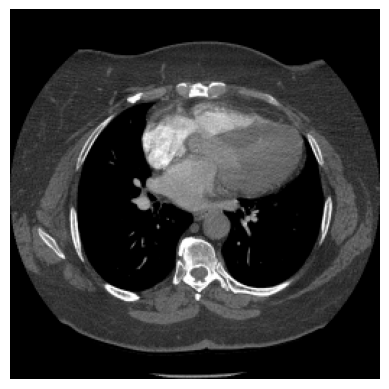

In [3]:
#3
import glob, time
import numpy as np, pydicom, cv2
import matplotlib.pyplot as plt

keep_slices = 64                     # change this if you want more/fewer
save_here = "/kaggle/working/scans"
os.makedirs(save_here, exist_ok=True)

def window_it(hu, center=100, width=700):
    lo, hi = center - width / 2, center + width / 2
    return ((np.clip(hu, lo, hi) - lo) / (hi - lo) * 255).astype(np.uint8)

def squish_patient(pid):
    out = f"{save_here}/{pid}.npz"
    if os.path.exists(out):
        return pid, "already done"
    try:
        files = glob.glob(f"{data_home}/train/{pid}/*/*.dcm")

        # headers only (fast) -> where each slice sits in the body
        spots = []
        for f in files:
            h = pydicom.dcmread(f, stop_before_pixels=True)
            spots.append((float(h.ImagePositionPatient[2]), f))
        spots.sort()   # head-to-toe order

        # pick 64 evenly spaced slices
        picks = np.linspace(0, len(spots) - 1, keep_slices).round().astype(int)

        imgs, ids = [], []
        for i in picks:
            d = pydicom.dcmread(spots[i][1])
            hu = d.pixel_array.astype(np.float32) * float(d.RescaleSlope) + float(d.RescaleIntercept)
            imgs.append(cv2.resize(window_it(hu), (256, 256)))
            ids.append(os.path.basename(spots[i][1])[:-4])

        np.savez_compressed(out, imgs=np.stack(imgs), ids=np.array(ids))
        return pid, len(files)      # how many slices the patient originally had
    except Exception as e:
        return pid, f"ERROR: {e}"

# test on one patient
lucky_one = picked.StudyInstanceUID.iloc[0]
t = time.time()
print(squish_patient(lucky_one))
print("seconds:", round(time.time() - t, 1))

# peek at the middle slice
stuff = np.load(f"{save_here}/{lucky_one}.npz")
print("shape:", stuff["imgs"].shape)          # should be (64, 256, 256)
plt.imshow(stuff["imgs"][32], cmap="gray"); plt.axis("off"); plt.show()

### 4. preprocessing: all patients in parallel
the same function runs on all 3000 patients, 4 at a time (one per cpu core). already-processed patients are skipped, so the cell can be rerun safely after a crash.

In [4]:
#4
import multiprocessing as mp

all_pids = picked.StudyInstanceUID.tolist()
oopsies = []
t = time.time()

# "fork" = each worker gets a copy of everything already defined (data_home, save_here, the function)
with mp.get_context("fork").Pool(4) as pool:
    for n, (pid, res) in enumerate(pool.imap_unordered(squish_patient, all_pids), 1):
        if isinstance(res, str) and res.startswith("ERROR"):
            oopsies.append((pid, res))
        if n % 25 == 0 or n == len(all_pids):
            spent = time.time() - t
            left = spent / n * (len(all_pids) - n)
            print(f"{n}/{len(all_pids)} done | {spent/60:.1f} min so far | ~{left/60:.1f} min left")

print("failed:", len(oopsies))
for o in oopsies[:5]:
    print(o)

print("files saved:", len(glob.glob(f"{save_here}/*.npz")))
!du -sh /kaggle/working/scans

25/3000 done | 0.0 min so far | ~0.1 min left
50/3000 done | 0.0 min so far | ~0.1 min left
75/3000 done | 0.0 min so far | ~0.1 min left
100/3000 done | 0.0 min so far | ~0.0 min left
125/3000 done | 0.0 min so far | ~0.0 min left
150/3000 done | 0.0 min so far | ~0.0 min left
175/3000 done | 0.0 min so far | ~0.0 min left
200/3000 done | 0.0 min so far | ~0.0 min left
225/3000 done | 0.0 min so far | ~0.0 min left
250/3000 done | 0.0 min so far | ~0.0 min left
275/3000 done | 0.0 min so far | ~0.0 min left
300/3000 done | 0.0 min so far | ~0.0 min left
325/3000 done | 0.0 min so far | ~0.0 min left
350/3000 done | 0.0 min so far | ~0.0 min left
375/3000 done | 0.0 min so far | ~0.0 min left
400/3000 done | 0.0 min so far | ~0.0 min left
425/3000 done | 0.0 min so far | ~0.0 min left
450/3000 done | 0.0 min so far | ~0.0 min left
475/3000 done | 0.0 min so far | ~0.0 min left
500/3000 done | 0.0 min so far | ~0.0 min left
525/3000 done | 0.0 min so far | ~0.0 min left
550/3000 done | 

### 5. load the scans and build the slice table
all patient files are loaded into memory, and every kept slice becomes one row: patient, slice position, **clot / no clot** (`pe_present_on_image`) and split. we also count sick patients whose clot fell between the 64 kept slices, a known limitation of the sampling.

In [5]:
#5
from tqdm.auto import tqdm

split_of = {}
for name, chunk in [("train", train_pts), ("val", val_pts), ("test", test_pts)]:
    for pid in chunk.StudyInstanceUID:
        split_of[pid] = name

clot_of = dict(zip(df.SOPInstanceUID, df.pe_present_on_image))   # slice id -> clot or not
patient_sick = dict(zip(pts.StudyInstanceUID, pts.has_pe))        # patient -> sick or not

scans, rows = {}, []
for pid in tqdm(split_of):
    f = f"{save_here}/{pid}.npz"
    if not os.path.exists(f):
        continue
    stuff = np.load(f)
    scans[pid] = stuff["imgs"]
    for i, sid in enumerate(stuff["ids"]):
        rows.append((pid, i, int(clot_of[sid]), split_of[pid]))

table = pd.DataFrame(rows, columns=["pid", "idx", "clot", "split"])

print("patients loaded:", len(scans))
for name in ["train", "val", "test"]:
    part = table[table.split == name]
    print(f"{name}: {len(part)} slices | clot slices: {part.clot.sum()} ({part.clot.mean():.1%})")

clots_per_pt = table.groupby("pid").clot.sum()
sick_ones = [p for p in scans if patient_sick[p] == 1]
lost = [p for p in sick_ones if clots_per_pt[p] == 0]
print(f"sick patients with no clot in kept slices: {len(lost)} of {len(sick_ones)}")

import gc
del clot_of, rows
gc.collect()

  0%|          | 0/3000 [00:00<?, ?it/s]

patients loaded: 3000
train: 134400 slices | clot slices: 7680 (5.7%)
val: 28800 slices | clot slices: 1573 (5.5%)
test: 28800 slices | clot slices: 1876 (6.5%)
sick patients with no clot in kept slices: 16 of 932


63

### 6. dataset, augmentation and class imbalance
- **2.5d input:** each image is 3 neighboring slices stacked as the 3 color channels (above, current, below), giving the model some 3d context while staying a 2d model
- **augmentation (training only):** small zoom, shift, ±5° rotation, contrast, brightness and light noise, mimicking real differences between patients and scanners. no flips, since chest anatomy is not symmetric
- **normalization:** pixels are scaled the way imagenet-pretrained models expect
- **imbalance:** only ~5% of slices contain a clot, so `pos_weight` (healthy slices ÷ clot slices) makes a missed clot cost much more in the loss than a false alarm

In [6]:
#6
import torch, random
from torch.utils.data import Dataset, DataLoader

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def jiggle(img):                                   # img: (256, 256, 3)
    img = img.astype(np.float32)
    zoom = random.uniform(0.9, 1.1)
    dx, dy = random.uniform(-10, 10), random.uniform(-10, 10)
    move = cv2.getRotationMatrix2D((128, 128), random.uniform(-5, 5), zoom)
    move[0, 2] += dx
    move[1, 2] += dy
    img = cv2.warpAffine(img, move, (256, 256), borderValue=0)
    avg = img.mean()
    img = (img - avg) * random.uniform(0.85, 1.15) + avg      # contrast
    img = img + random.uniform(-15, 15)                         # brightness
    if random.random() < 0.5:
        img = img + np.random.normal(0, 4, img.shape)           # light noise
    return np.clip(img, 0, 255)

class SliceSet(Dataset):
    def __init__(self, chunk, train):
        self.rows = chunk.reset_index(drop=True)
        self.train = train
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, k):
        pid, i, clot = self.rows.pid[k], self.rows.idx[k], self.rows.clot[k]
        vol = scans[pid]
        last = len(vol) - 1
        img = np.stack([vol[max(i - 1, 0)], vol[i], vol[min(i + 1, last)]], axis=-1)
        img = jiggle(img) if self.train else img.astype(np.float32)
        img = (img / 255 - mean) / std
        img = torch.from_numpy(img.transpose(2, 0, 1).copy()).float()
        return img, torch.tensor(clot, dtype=torch.float32), pid

train_rows = table[table.split == "train"]
val_rows   = table[table.split == "val"]
test_rows  = table[table.split == "test"]

train_dl = DataLoader(SliceSet(train_rows, True),  batch_size=32, shuffle=True,  num_workers=2, persistent_workers=True)
val_dl   = DataLoader(SliceSet(val_rows,   False), batch_size=64, shuffle=False, num_workers=2, persistent_workers=True)
test_dl  = DataLoader(SliceSet(test_rows,  False), batch_size=64, shuffle=False, num_workers=2, persistent_workers=True)

n_clot = train_rows.clot.sum()
n_fine = len(train_rows) - n_clot
assert n_clot > 0, "NO CLOT LABELS IN TRAIN, STOP AND CHECK CELL 5"
pos_weight = torch.tensor([n_fine / n_clot])
print("pos_weight:", round(pos_weight.item(), 1))

imgs, clots, _ = next(iter(train_dl))
print("batch shape:", imgs.shape)

pos_weight: 16.5
batch shape: torch.Size([32, 3, 256, 256])


### 6.5 visual check: original vs augmented
three clot slices and three healthy slices, each shown untouched and with two random augmentations, to confirm the augmentation changes the image realistically without destroying it. the brightness range is fixed (0–255) so brightness changes stay visible.

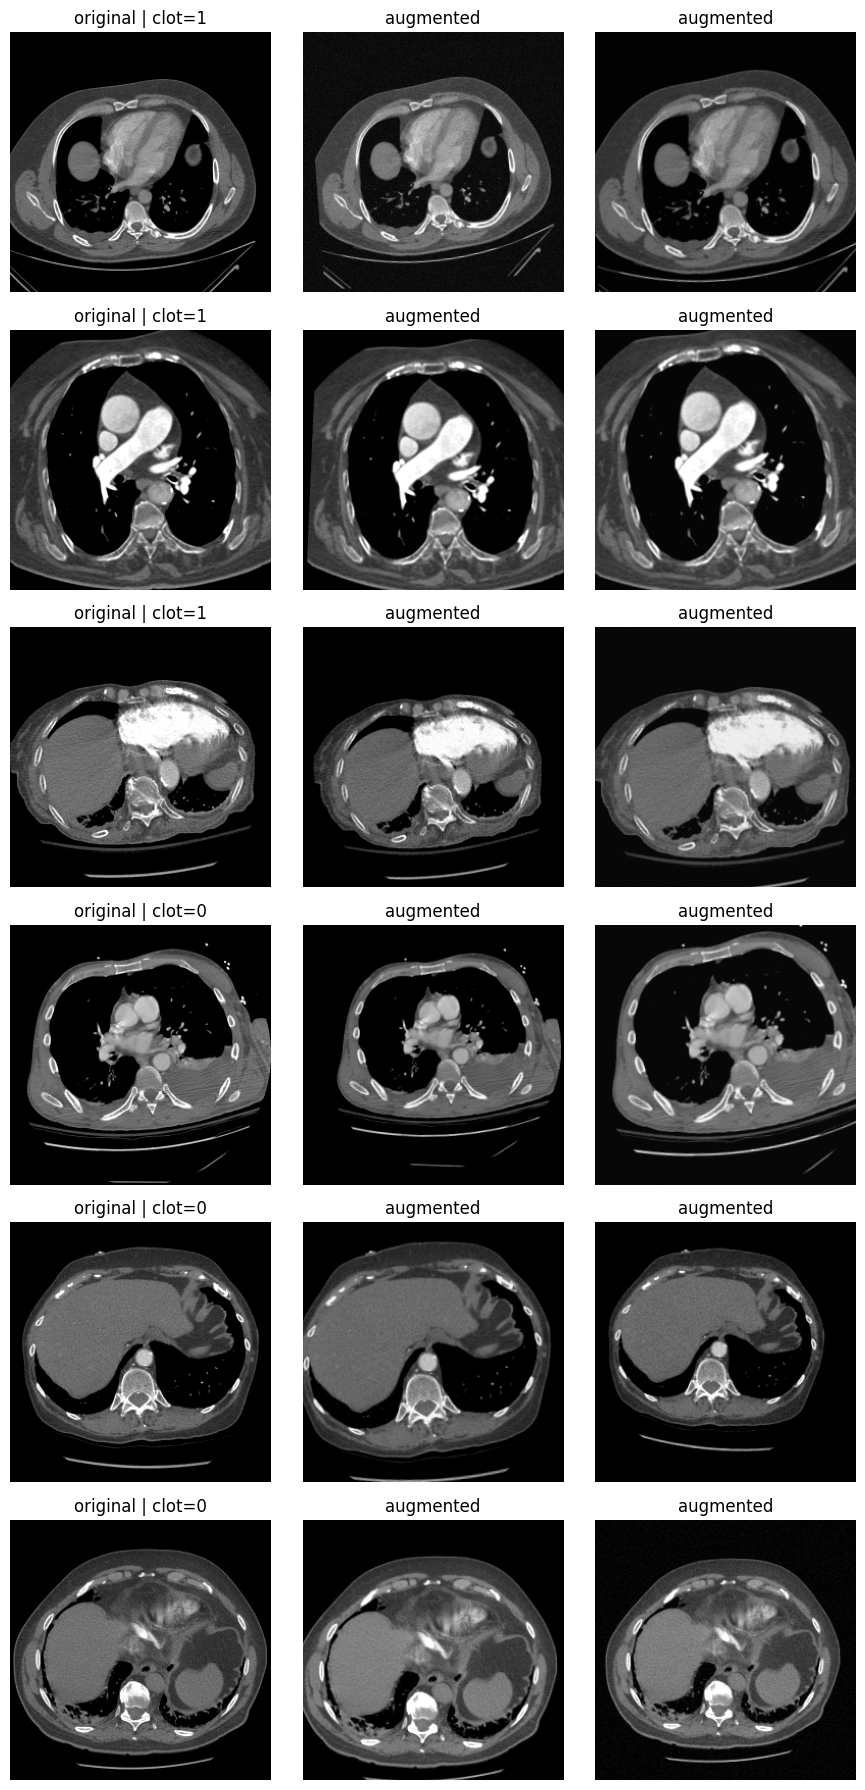

device: cuda
training 11,019,521 of 11,177,025 parameters
output shape: torch.Size([4, 1])


In [7]:
#6.5 visualization
import torchvision

# ---------- part 1: original vs augmented ----------
show = pd.concat([
    train_rows[train_rows.clot == 1].sample(3, random_state=1),
    train_rows[train_rows.clot == 0].sample(3, random_state=1),
])

fig, axes = plt.subplots(6, 3, figsize=(9, 18))
for r, (_, row) in enumerate(show.iterrows()):
    vol = scans[row.pid]
    i, last = row.idx, len(vol) - 1
    trio = np.stack([vol[max(i - 1, 0)], vol[i], vol[min(i + 1, last)]], axis=-1)

    axes[r, 0].imshow(trio[:, :, 1], cmap="gray", vmin=0, vmax=255)
    axes[r, 0].set_title(f"original | clot={row.clot}")
    for c in (1, 2):
        axes[r, c].imshow(jiggle(trio)[:, :, 1], cmap="gray", vmin=0, vmax=255)
        axes[r, c].set_title("augmented")
    for ax in axes[r]:
        ax.axis("off")
plt.tight_layout(); plt.show()

# ---------- part 2: the model ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)                           # should say cuda

### 7. evaluation helper
`show_results` loads a model's best saved weights, scores every validation patient (patient score = average of their 5 most suspicious slices) and shows confusion matrices at two cutoffs: the default 0.5, and the cutoff that reaches 90% recall.

In [17]:
#7
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, roc_curve

def show_results(weights_file, title):
    model.load_state_dict(torch.load(weights_file))      # best epoch of the model currently in `model`
    model.eval()

    got = []
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for x, y, pids in val_dl:
            probs = torch.sigmoid(model(x.to(device)).squeeze(1)).float().cpu().numpy()
            got += list(zip(pids, probs))
    sl = pd.DataFrame(got, columns=["pid", "prob"])
    val_pt = sl.groupby("pid").prob.apply(lambda s: s.nlargest(5).mean())
    y_true, scores = val_pt.index.map(patient_sick).values, val_pt.values

    fpr, tpr, cuts = roc_curve(y_true, scores)
    cut90 = cuts[np.argmax(tpr >= 0.90)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14)
    for ax, cut, name in [(axes[0], 0.5, "default cutoff"), (axes[1], cut90, "cutoff for 90% recall")]:
        pred = (scores >= cut).astype(int)
        ConfusionMatrixDisplay(confusion_matrix(y_true, pred), display_labels=["healthy", "pe"]).plot(ax=ax, colorbar=False)
        r, p, f = recall_score(y_true, pred), precision_score(y_true, pred), f1_score(y_true, pred)
        ax.set_title(f"{name} ({cut:.2f})\nrecall {r:.2f} | precision {p:.2f} | f1 {f:.2f}")
        print(f"{title} | {name} ({cut:.2f}): recall {r:.2f} | precision {p:.2f} | f1 {f:.2f}")
    plt.tight_layout(); plt.show()

### 8. model 1: pe_ct_cnn (baseline, from scratch)
a small 4-block cnn (~100k parameters) with no pretraining, trained only on our ct slices. it answers: how far do we get with no prior knowledge? after each epoch we measure patient-level validation auc and keep the best epoch, with early stopping after 2 epochs without improvement.

In [ ]:
#8
from sklearn.metrics import roc_auc_score

# patient score = their highest slice score (used to check val after each epoch)
def patient_scores(dl):
    model.eval()
    top = {}
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for x, _, pids in dl:
            probs = torch.sigmoid(model(x.to(device)).squeeze(1)).float().cpu().numpy()
            for pid, s in zip(pids, probs):
                top[pid] = max(top.get(pid, 0.0), float(s))
    res = pd.DataFrame({"pid": list(top), "score": list(top.values())})
    res["sick"] = res.pid.map(patient_sick)
    return res

# ---------- baseline: pe_ct_cnn, a small cnn trained from scratch ----------
class pe_ct_cnn(torch.nn.Module):
    def __init__(self):
        super().__init__()
        def block(cin, cout):              # conv -> normalize -> activate -> shrink image by half
            return torch.nn.Sequential(torch.nn.Conv2d(cin, cout, 3, padding=1),
                                       torch.nn.BatchNorm2d(cout), torch.nn.ReLU(), torch.nn.MaxPool2d(2))
        self.body = torch.nn.Sequential(block(3, 16), block(16, 32), block(32, 64), block(64, 128),
                                        torch.nn.AdaptiveAvgPool2d(1), torch.nn.Flatten())
        self.head = torch.nn.Linear(128, 1)
    def forward(self, x):
        return self.head(self.body(x))

model = pe_ct_cnn().to(device)        # random start, nothing pretrained, nothing to freeze
print(f"pe_ct_cnn parameters: {sum(p.numel() for p in model.parameters()):,}")

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
epochs, patience = 8, 2
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=epochs * len(train_dl))
scaler = torch.amp.GradScaler("cuda")

history_pe_ct_cnn, best_auc, bad_epochs = [], 0, 0
for ep in range(1, epochs + 1):
    model.train()
    t, total = time.time(), 0
    for x, y, _ in tqdm(train_dl, leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        with torch.amp.autocast("cuda"):
            loss = loss_fn(model(x).squeeze(1), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        sched.step()
        total += loss.item()

    val = patient_scores(val_dl)
    auc = roc_auc_score(val.sick, val.score)
    history_pe_ct_cnn.append((total / len(train_dl), auc))
    print(f"\n========== epoch {ep} of {epochs} ({(time.time()-t)/60:.1f} min) ==========")
    print(f"training loss (lower = fits training data better): {total/len(train_dl):.3f}")
    print(f"validation ranking score / auc (0.5 = guessing, 1.0 = perfect): {auc:.3f}")

    if auc > best_auc:
        best_auc, bad_epochs = auc, 0
        torch.save(model.state_dict(), "/kaggle/working/best_pe_ct_cnn.pt")
        print("   -> best so far, model saved")
    else:
        bad_epochs += 1
        print(f"   no improvement ({bad_epochs}/{patience})")
        if bad_epochs >= patience:
            print("   stopping early")
            break

print(f"\nbest validation auc (pe_ct_cnn): {best_auc:.3f}")

### 9. pe_ct_cnn training summary
training loss and validation auc per epoch, reprinted from the saved training history. pe_ct_cnn's best auc 0.590

In [11]:
#9
print("pe_ct_cnn training summary")
for ep, (loss, auc) in enumerate(history_pe_ct_cnn, 1):
    print(f"epoch {ep}: training loss {loss:.3f} | validation auc {auc:.3f}")
print(f"\nbest validation auc (pe_ct_cnn): {max(a for _, a in history_pe_ct_cnn):.3f}")

pe_ct_cnn training summary
epoch 1: training loss 1.046 | validation auc 0.493
epoch 2: training loss 0.955 | validation auc 0.556
epoch 3: training loss 0.920 | validation auc 0.590
epoch 4: training loss 0.899 | validation auc 0.579
epoch 5: training loss 0.880 | validation auc 0.558

best validation auc (pe_ct_cnn): 0.590


### 10. pe_ct_cnn results
confusion matrices of the baseline on the validation patients.

pe_ct_cnn (baseline) | default cutoff (0.50): recall 1.00 | precision 0.31 | f1 0.48
pe_ct_cnn (baseline) | cutoff for 90% recall (0.86): recall 0.90 | precision 0.33 | f1 0.48


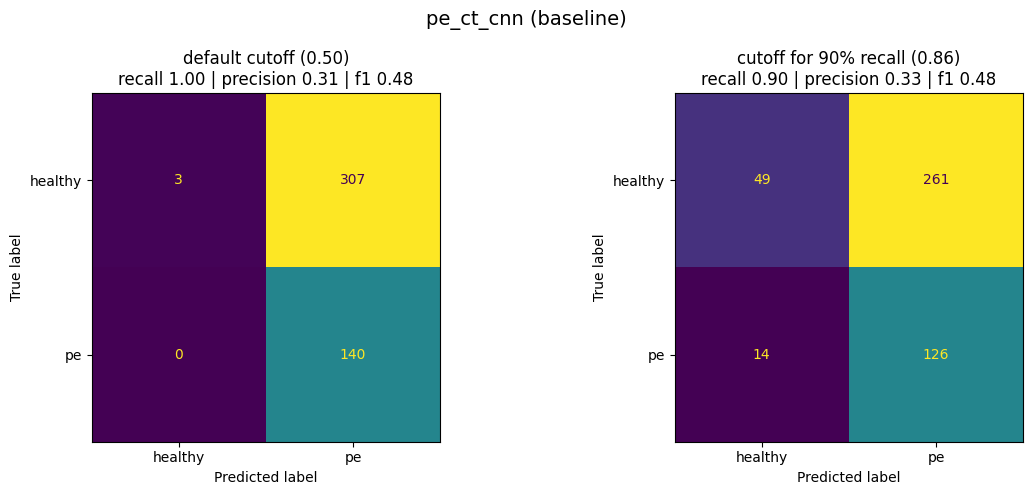

In [18]:
#10
show_results("/kaggle/working/best_pe_ct_cnn.pt", "pe_ct_cnn (baseline)")

### 11. model 2: resnet18 (transfer learning)
resnet18 pretrained on imagenet, with the first layers (conv1, bn1, layer1) frozen and the rest fine-tuned on our slices. trained for 4 epochs; the epoch with the best validation auc is kept.

**result:** best validation auc **0.705**. epoch 4 shows the training loss dropping sharply while validation auc stays flat, the first sign of overfitting, which is why we keep the best epoch rather than the last.

In [25]:
#11
from sklearn.metrics import roc_auc_score

# build a FRESH pretrained resnet18 every time this cell runs
model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
model.fc = torch.nn.Linear(model.fc.in_features, 1)
model = model.to(device)

for name, p in model.named_parameters():
    if name.startswith(("conv1", "bn1", "layer1")):
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
everything = sum(p.numel() for p in model.parameters())
print(f"resnet18: training {trainable:,} of {everything:,} parameters")

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
epochs = 4
patience = 99        # not using early stopping here
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=epochs * len(train_dl))
scaler = torch.amp.GradScaler("cuda")

# patient score = their highest slice score
def patient_scores(dl):
    model.eval()
    top = {}
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for x, _, pids in dl:
            probs = torch.sigmoid(model(x.to(device)).squeeze(1)).float().cpu().numpy()
            for pid, s in zip(pids, probs):
                top[pid] = max(top.get(pid, 0.0), float(s))
    res = pd.DataFrame({"pid": list(top), "score": list(top.values())})
    res["sick"] = res.pid.map(patient_sick)
    return res

bad_epochs = 0
best_auc = 0
for ep in range(1, epochs + 1):
    model.train()
    t, total = time.time(), 0
    for x, y, _ in tqdm(train_dl, leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        with torch.amp.autocast("cuda"):
            loss = loss_fn(model(x).squeeze(1), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        sched.step()
        total += loss.item()

    val = patient_scores(val_dl)
    auc = roc_auc_score(val.sick, val.score)
    said_sick = val.score >= 0.5
    recall = (said_sick & (val.sick == 1)).sum() / (val.sick == 1).sum()
    print(f"epoch {ep} | loss {total/len(train_dl):.3f} | val auc {auc:.3f} | "
          f"recall@0.5 {recall:.2f} | {(time.time()-t)/60:.1f} min")

    if auc > best_auc:
        best_auc = auc
        bad_epochs = 0
        torch.save(model.state_dict(), "/kaggle/working/best_resnet18_frozen.pt")
        print("   saved (best so far)")
    else:
        bad_epochs += 1
        print(f"   no improvement ({bad_epochs}/{patience})")
        if bad_epochs >= patience:
            print("   stopping early")
            break

print("best val auc:", round(best_auc, 3))

resnet18: training 11,019,521 of 11,177,025 parameters


  0%|          | 0/4200 [00:00<?, ?it/s]

/tmp/ipykernel_333/3244186669.py:50: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


epoch 1 | loss 0.835 | val auc 0.625 | recall@0.5 0.97 | 8.9 min
   saved (best so far)


  0%|          | 0/4200 [00:00<?, ?it/s]

epoch 2 | loss 0.747 | val auc 0.689 | recall@0.5 0.94 | 8.9 min
   saved (best so far)


  0%|          | 0/4200 [00:00<?, ?it/s]

epoch 3 | loss 0.611 | val auc 0.705 | recall@0.5 0.99 | 8.9 min
   saved (best so far)


  0%|          | 0/4200 [00:00<?, ?it/s]

epoch 4 | loss 0.424 | val auc 0.701 | recall@0.5 0.99 | 8.9 min
   no improvement (1/99)
best val auc: 0.705


### 12. resnet18 results
confusion matrices of resnet18 on the validation patients.

resnet18 | default cutoff (0.50): recall 0.96 | precision 0.32 | f1 0.48
resnet18 | cutoff for 90% recall (0.70): recall 0.90 | precision 0.34 | f1 0.50


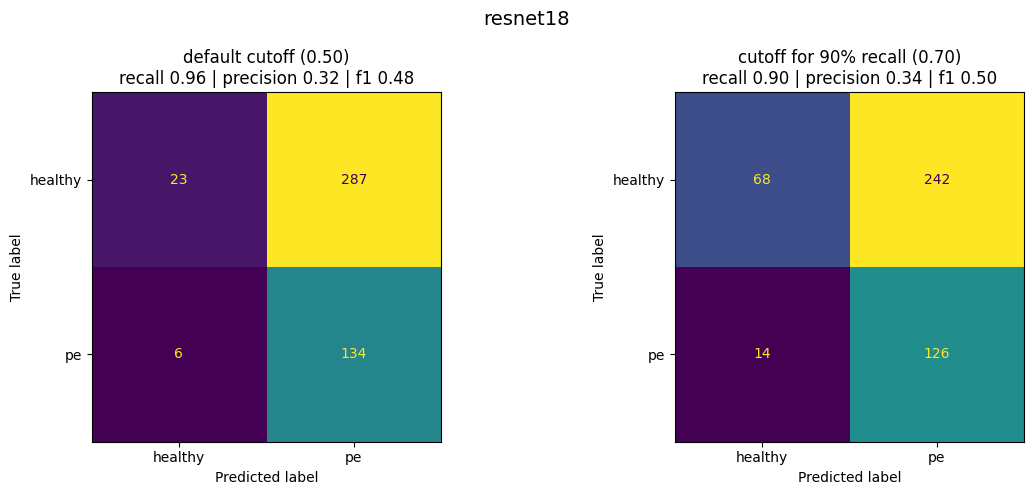

In [27]:
#12
show_results("/kaggle/working/best_resnet18_frozen.pt", "resnet18")

### 13. model 3: efficientnet-b0 (transfer learning, newer architecture)
efficientnet-b0 pretrained on imagenet, early feature stages (0–2) frozen, same training setup as resnet18 for a fair comparison.

**result:** best validation auc **0.729**, ahead of resnet18 at every epoch. efficientnet-b0 is our winning slice model.

In [28]:
#13
from sklearn.metrics import roc_auc_score

# ---------- model 3: efficientnet-b0, pretrained + fine-tuned ----------
model = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)

# freeze the early layers, same idea as with resnet
for name, p in model.named_parameters():
    if name.startswith(("features.0.", "features.1.", "features.2.")):
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
everything = sum(p.numel() for p in model.parameters())
print(f"efficientnet-b0: training {trainable:,} of {everything:,} parameters")

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
epochs, patience = 4, 99 #no early stopping here as well
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=epochs * len(train_dl))
scaler = torch.amp.GradScaler("cuda")

history_effnet, best_auc, bad_epochs = [], 0, 0
for ep in range(1, epochs + 1):
    model.train()
    t, total = time.time(), 0
    for x, y, _ in tqdm(train_dl, leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        with torch.amp.autocast("cuda"):
            loss = loss_fn(model(x).squeeze(1), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        sched.step()
        total += loss.item()

    val = patient_scores(val_dl)                     # defined in the pe_ct_cnn cell
    auc = roc_auc_score(val.sick, val.score)
    history_effnet.append((total / len(train_dl), auc))
    print(f"\n========== epoch {ep} of {epochs} ({(time.time()-t)/60:.1f} min) ==========")
    print(f"training loss (lower = fits training data better): {total/len(train_dl):.3f}")
    print(f"validation ranking score / auc (0.5 = guessing, 1.0 = perfect): {auc:.3f}")

    if auc > best_auc:
        best_auc, bad_epochs = auc, 0
        torch.save(model.state_dict(), "/kaggle/working/best_effnet.pt")
        print("   -> best so far, model saved")
    else:
        bad_epochs += 1
        print(f"   no improvement ({bad_epochs}/{patience})")
        if bad_epochs >= patience:
            print("   stopping early")
            break

print(f"\nbest validation auc (efficientnet-b0): {best_auc:.3f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 214MB/s]

efficientnet-b0: training 3,989,739 of 4,008,829 parameters


  0%|          | 0/4200 [00:00<?, ?it/s]


========== epoch 1 of 4 (9.5 min) ==========
training loss (lower = fits training data better): 0.876
validation ranking score / auc (0.5 = guessing, 1.0 = perfect): 0.668
   -> best so far, model saved


...


========== epoch 2 of 4 (9.4 min) ==========
training loss (lower = fits training data better): 0.735
validation ranking score / auc (0.5 = guessing, 1.0 = perfect): 0.714
   -> best so far, model saved


  0%|          | 0/4200 [00:00<?, ?it/s]


========== epoch 3 of 4 (9.3 min) ==========
training loss (lower = fits training data better): 0.580
validation ranking score / auc (0.5 = guessing, 1.0 = perfect): 0.729
   -> best so far, model saved


  0%|          | 0/4200 [00:00<?, ?it/s]


========== epoch 4 of 4 (9.3 min) ==========
training loss (lower = fits training data better): 0.399
validation ranking score / auc (0.5 = guessing, 1.0 = perfect): 0.716
   no improvement (1/99)

best validation auc (efficientnet-b0): 0.729


### 14. efficientnet-b0 results
confusion matrices of efficientnet-b0 on the validation patients.

efficientnet-b0 | default cutoff (0.50): recall 0.97 | precision 0.34 | f1 0.51
efficientnet-b0 | cutoff for 90% recall (0.68): recall 0.91 | precision 0.37 | f1 0.53


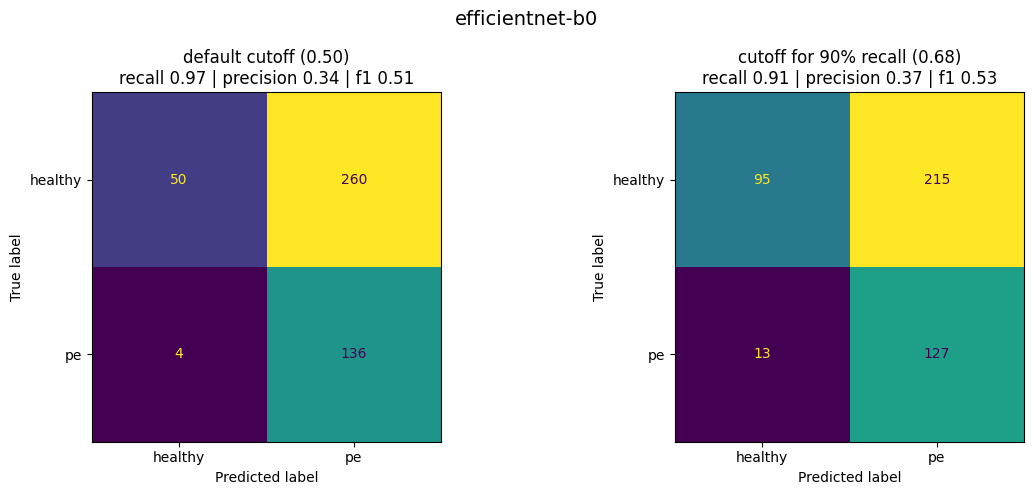

In [29]:
#14
show_results("/kaggle/working/best_effnet.pt", "efficientnet-b0")

### 15. from slices to patients
efficientnet-b0 scores every validation and test slice. each patient's score is the **average of their 5 most suspicious slices**. (a learned patient-level model was also tested and did not beat this simple rule.)

In [37]:
#15
from sklearn.metrics import roc_curve, roc_auc_score

# ---------- load the winning slice model (efficientnet-b0) ----------
model = torchvision.models.efficientnet_b0(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
model.load_state_dict(torch.load("/kaggle/working/best_effnet.pt"))
model = model.to(device).eval()

# ---------- score every val + test slice ----------
def score_slices(rows, dl):
    probs = []
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for x, _, _ in tqdm(dl, leave=False):
            probs.append(torch.sigmoid(model(x.to(device)).squeeze(1)).float().cpu().numpy())
    return rows.assign(prob=np.concatenate(probs))

val_scored  = score_slices(val_rows, val_dl)
test_scored = score_slices(test_rows, test_dl)

# ---------- patient score = average of their 5 most suspicious slices ----------
def patient_top5(scored):
    top5 = scored.groupby("pid").prob.apply(lambda s: s.nlargest(5).mean())
    return pd.DataFrame({"top5": top5}), top5.index.map(patient_sick).values

X_val, y_val   = patient_top5(val_scored)
X_test, y_test = patient_top5(test_scored)
print("val patients:", len(X_val), "| test patients:", len(X_test))
print("val patient auc (top-5 average):", round(roc_auc_score(y_val, X_val["top5"]), 3))

  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/450 [00:00<?, ?it/s]

val patients: 450 | test patients: 450
val patient auc (top-5 average): 0.739


### 15.5 final test (run once)
the decision cutoff is chosen on **validation** to reach 90% recall, then applied unchanged to the **test** patients, who were never used for any decision during development.

**result:** test auc **0.778**; recall **0.90** (126 of 140 sick patients caught), precision **0.38**, specificity **0.33**. the validation-chosen cutoff produced exactly the targeted recall on unseen patients, showing the threshold generalizes.

cutoff picked on val: 0.681
test auc:         0.778
test recall:      0.90  (sick caught: 126 of 140)
test precision:   0.38
test specificity: 0.33  (healthy cleared: 101 of 310)
test f1:          0.53


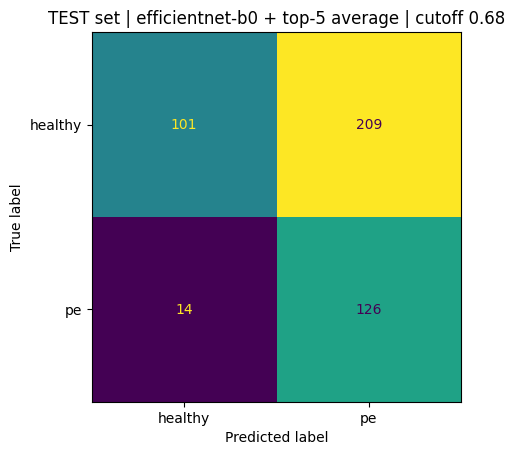

In [38]:
#15.5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# cutoff chosen on VAL (90% recall), then applied to TEST unchanged
fpr, tpr, cuts = roc_curve(y_val, X_val["top5"].values)
final_cut = cuts[np.argmax(tpr >= 0.90)]
print(f"cutoff picked on val: {final_cut:.3f}")

test_s = X_test["top5"].values
pred = (test_s >= final_cut).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

print(f"test auc:         {roc_auc_score(y_test, test_s):.3f}")
print(f"test recall:      {tp/(tp+fn):.2f}  (sick caught: {tp} of {tp+fn})")
print(f"test precision:   {tp/(tp+fp):.2f}")
print(f"test specificity: {tn/(tn+fp):.2f}  (healthy cleared: {tn} of {tn+fp})")
print(f"test f1:          {f1_score(y_test, pred):.2f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["healthy", "pe"]).plot(colorbar=False)
plt.title(f"TEST set | efficientnet-b0 + top-5 average | cutoff {final_cut:.2f}")
plt.show()

### 16. test report: roc, precision-recall and calibration
- **roc curve:** recall vs false alarm rate across all cutoffs
- **precision-recall curve:** more informative than roc for imbalanced data; the dashed line is what flagging everyone would give
- **calibration:** scores are **not** calibrated probabilities. the class weighting pushes them upward, so decisions rely on the validation-tuned cutoff rather than reading scores as percentages

shown at patient level (our main result) and slice level.

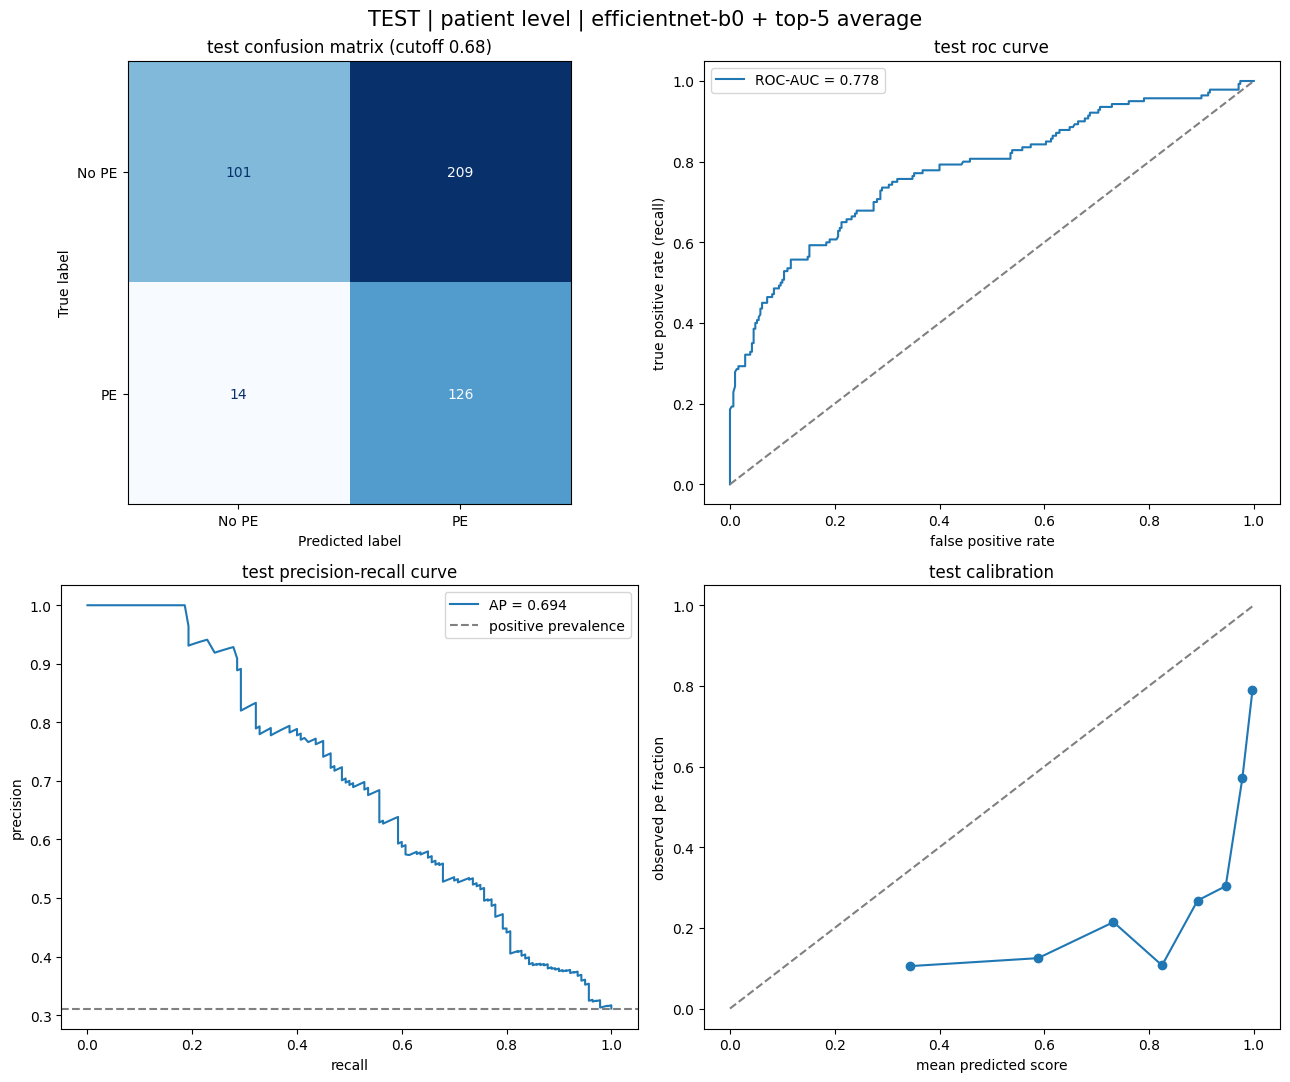

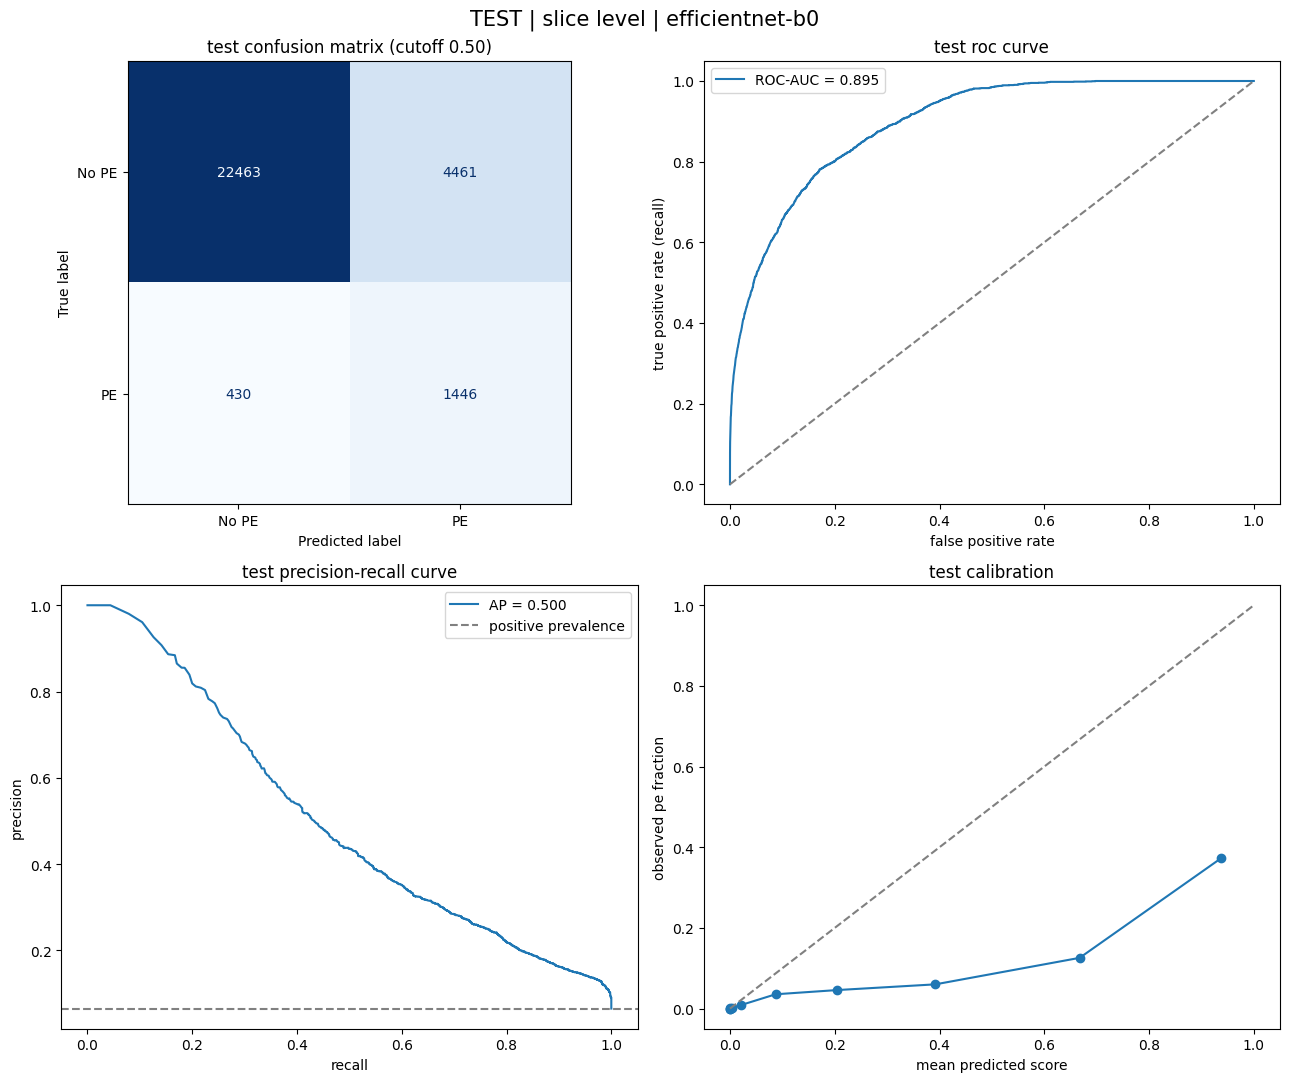

In [39]:
#16
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

def report_plots(y, s, cut, title, bins=8):
    y, s = np.asarray(y), np.asarray(s)
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    fig.suptitle(title, fontsize=15)

    # 1. confusion matrix
    pred = (s >= cut).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y, pred), display_labels=["No PE", "PE"]).plot(
        ax=axes[0, 0], cmap="Blues", colorbar=False, values_format="d")
    axes[0, 0].set_title(f"test confusion matrix (cutoff {cut:.2f})")

    # 2. roc curve
    fpr, tpr, _ = roc_curve(y, s)
    axes[0, 1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y, s):.3f}")
    axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
    axes[0, 1].set(title="test roc curve", xlabel="false positive rate", ylabel="true positive rate (recall)")
    axes[0, 1].legend()

    # 3. precision-recall curve
    prec, rec, _ = precision_recall_curve(y, s)
    axes[1, 0].plot(rec, prec, label=f"AP = {average_precision_score(y, s):.3f}")
    axes[1, 0].axhline(y.mean(), ls="--", color="gray", label="positive prevalence")
    axes[1, 0].set(title="test precision-recall curve", xlabel="recall", ylabel="precision")
    axes[1, 0].legend()

    # 4. calibration: when the model says 60%, is it really pe 60% of the time?
    frac_pe, mean_score = calibration_curve(y, s, n_bins=bins, strategy="quantile")
    axes[1, 1].plot(mean_score, frac_pe, "o-")
    axes[1, 1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1, 1].set(title="test calibration", xlabel="mean predicted score", ylabel="observed pe fraction")

    plt.tight_layout(); plt.show()

# patient level (your main result)
report_plots(y_test, X_test["top5"].values, final_cut,
             "TEST | patient level | efficientnet-b0 + top-5 average")

# slice level (like the example)
report_plots(test_scored.clot.values, test_scored.prob.values, 0.5,
             "TEST | slice level | efficientnet-b0", bins=10)

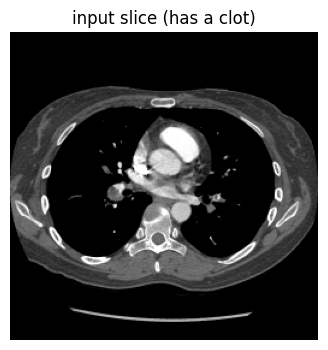

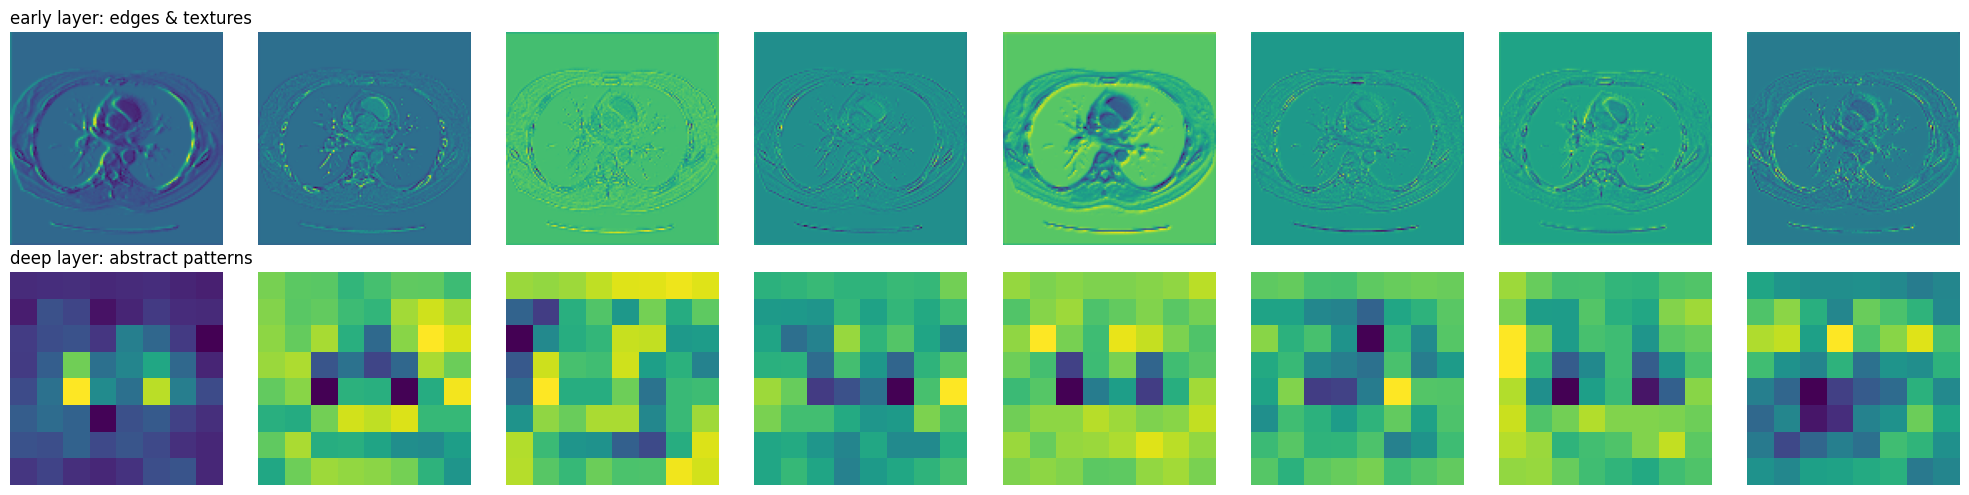

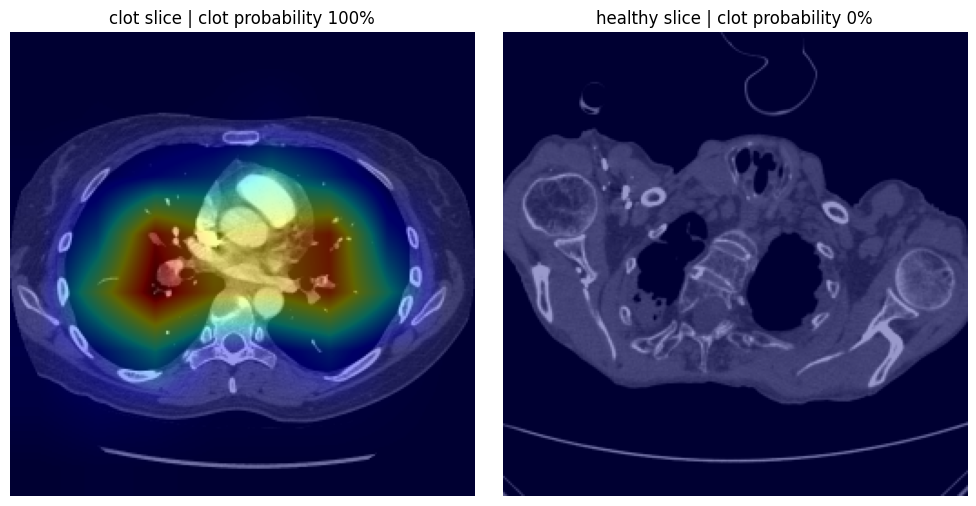

In [40]:
#17
def make_input(pid, i):                              # same 2.5d input as training, no augmentation
    vol = scans[pid]
    last = len(vol) - 1
    trio = np.stack([vol[max(i - 1, 0)], vol[i], vol[min(i + 1, last)]], axis=-1).astype(np.float32)
    x = (trio / 255 - mean) / std
    return torch.from_numpy(x.transpose(2, 0, 1).copy()).float().unsqueeze(0).to(device), vol[i]

caught  = test_scored[test_scored.clot == 1].sort_values("prob", ascending=False).iloc[0]   # clot slice it caught
cleared = test_scored[test_scored.clot == 0].sort_values("prob").iloc[0]                    # healthy slice it cleared

# ---------- 1. feature maps (8 filters from an early and a deep layer) ----------
x, raw = make_input(caught.pid, caught.idx)
grabbed = {}
hooks = [model.features[1].register_forward_hook(lambda m, i, o: grabbed.__setitem__("early", o.detach())),
         model.features[6].register_forward_hook(lambda m, i, o: grabbed.__setitem__("deep", o.detach()))]
with torch.no_grad():
    model(x)
for h in hooks:
    h.remove()

plt.figure(figsize=(4, 4)); plt.imshow(raw, cmap="gray"); plt.title("input slice (has a clot)"); plt.axis("off"); plt.show()
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for c in range(8):
    axes[0, c].imshow(grabbed["early"][0, c].cpu(), cmap="viridis"); axes[0, c].axis("off")
    axes[1, c].imshow(grabbed["deep"][0, c].cpu(), cmap="viridis"); axes[1, c].axis("off")
axes[0, 0].set_title("early layer: edges & textures", loc="left")
axes[1, 0].set_title("deep layer: abstract patterns", loc="left")
plt.tight_layout(); plt.show()

# ---------- 2. grad-cam: where did it look? ----------
def grad_cam(x):
    store = {}
    h = model.features[-1].register_forward_hook(lambda m, i, o: store.__setitem__("act", o))
    out = model(x)
    h.remove()
    act = store["act"]
    grads = torch.autograd.grad(out[0, 0], act)[0]
    heat = torch.relu((grads.mean(dim=(2, 3), keepdim=True) * act).sum(1))[0].detach().cpu().numpy()
    heat = cv2.resize(heat, (256, 256))
    return heat / (heat.max() + 1e-8), torch.sigmoid(out).item()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, row, name in [(axes[0], caught, "clot slice"), (axes[1], cleared, "healthy slice")]:
    x, raw = make_input(row.pid, row.idx)
    heat, p = grad_cam(x)
    ax.imshow(raw, cmap="gray")
    ax.imshow(heat, cmap="jet", alpha=0.4)
    ax.set_title(f"{name} | clot probability {p:.0%}"); ax.axis("off")
plt.tight_layout(); plt.show()

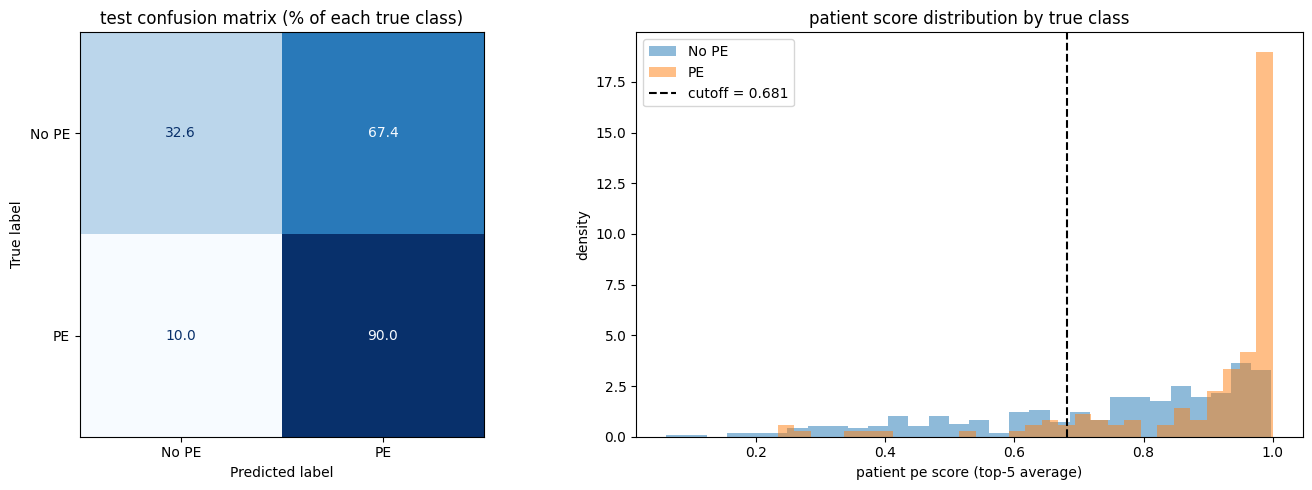

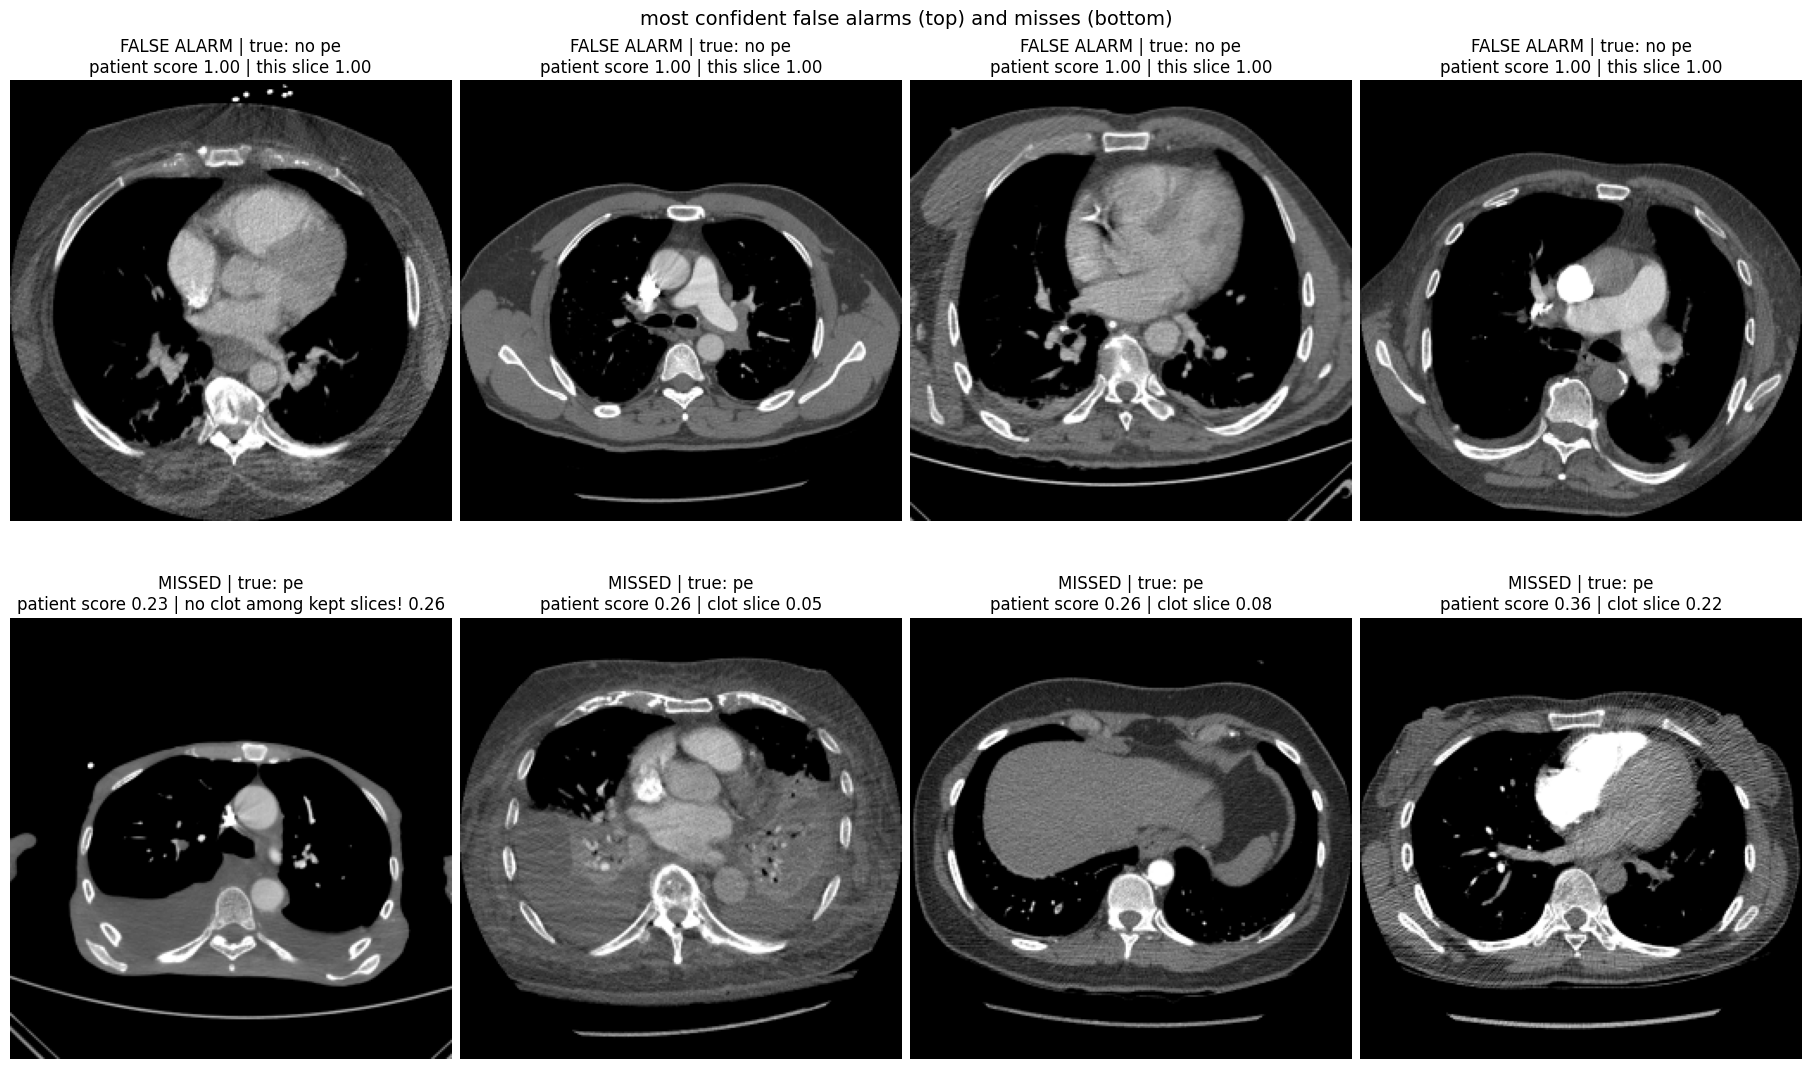

In [41]:
#18
pt = X_test["top5"]                                          # patient score, index = patient id
y = pt.index.map(patient_sick).values
pred = (pt.values >= final_cut).astype(int)

# ---------- 1. row-percentage confusion matrix + score distributions ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y, pred, normalize="true") * 100, display_labels=["No PE", "PE"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=".1f")
axes[0].set_title("test confusion matrix (% of each true class)")

axes[1].hist(pt[y == 0], bins=30, alpha=0.5, density=True, label="No PE")
axes[1].hist(pt[y == 1], bins=30, alpha=0.5, density=True, label="PE")
axes[1].axvline(final_cut, ls="--", color="black", label=f"cutoff = {final_cut:.3f}")
axes[1].set(title="patient score distribution by true class", xlabel="patient pe score (top-5 average)", ylabel="density")
axes[1].legend()
plt.tight_layout(); plt.show()

# ---------- 2. most confident mistakes ----------
n = 4
false_alarms = pt[(y == 0) & (pred == 1)].sort_values(ascending=False).head(n)   # healthy, scored most sick
misses       = pt[(y == 1) & (pred == 0)].sort_values().head(n)                  # sick, scored most healthy

fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 11), constrained_layout=True)
fig.suptitle("most confident false alarms (top) and misses (bottom)", fontsize=14)
for ax in axes.ravel():
    ax.axis("off")

for col, (pid, score) in enumerate(false_alarms.items()):
    sl = test_scored[test_scored.pid == pid]
    worst = sl.loc[sl.prob.idxmax()]                        # the slice that fooled it most
    axes[0, col].imshow(scans[pid][worst.idx], cmap="gray")
    axes[0, col].set_title(f"FALSE ALARM | true: no pe\npatient score {score:.2f} | this slice {worst.prob:.2f}", fontsize=12)

for col, (pid, score) in enumerate(misses.items()):
    sl = test_scored[test_scored.pid == pid]
    clots = sl[sl.clot == 1]
    if len(clots):
        show, note = clots.loc[clots.prob.idxmax()], "clot slice"
    else:
        show, note = sl.loc[sl.prob.idxmax()], "no clot among kept slices!"
    axes[1, col].imshow(scans[pid][show.idx], cmap="gray")
    axes[1, col].set_title(f"MISSED | true: pe\npatient score {score:.2f} | {note} {show.prob:.2f}", fontsize=12)

plt.show()